In [1]:
import os

print(os.environ['PYTHONHASHSEED'])

0


In [2]:
from gerrychain import Graph, Partition, MarkovChain, Election, updaters, constraints, accept
from gerrychain.proposals import recom
from gerrychain.constraints import contiguous
from gerrychain.tree import bipartition_tree
from functools import partial
import pandas as pd
import random
random.seed(2024)

In [3]:
# Load the graph in from the provided json file
graph = Graph.from_json("./PA_VTDs_clean.json")

# Set up election updater
election = Election("PRES12", {"Dem" : "PRES12D", "Rep": "PRES12R"})

# Set up updaters
my_updater = {
    "population": updaters.Tally("TOT_POP", alias="population"),
    "white_population": updaters.Tally("WHITE_POP", alias="white_population"),
    "cut_edges": updaters.cut_edges,
    "PRES12" : election
}

# Set up the initial partition object
initial_partition = Partition(
    graph,
    assignment = "2011_PLA_1",
    updaters = my_updater
)

ideal_population = sum(initial_partition["population"].values()) / len(initial_partition)
# print(f"ideal population: {ideal_population}")
print(list(initial_partition.updaters.keys()))
# create new function from the recom with our given arguments
proposal = partial(
    recom,
    pop_col="TOT_POP",
    pop_target=ideal_population,
    epsilon=0.01,
    node_repeats=2,
    method = partial(
        bipartition_tree,
        max_attempts=100,
        allow_pair_reselection=True 
    )
)

['cut_edges', 'population', 'white_population', 'PRES12']


In [33]:
def add_data_to_dataframe(plan_num, partition, dataframe):
    election_results = partition["PRES12"]
    districts = partition["population"].keys()

    dem_seats = election_results.seats("Dem")
    repub_seats = election_results.seats("Rep")

    total_population_dict = partition["population"]
    white_population_dict = partition["white_population"]

    dem_districts = []
    repub_districts = []
    # iterate through each district
    for district in districts:
        
        if election_results.won("Dem", district):
            dem_districts.append(district)
        else:
            repub_districts.append(district)


    row = pd.DataFrame([{"Repub Seats": repub_seats, "Demo Seats": dem_seats, 
                                "Repub Districts": repub_districts, "Demo Districts": dem_districts,
                                "Total Population by District": total_population_dict, "White Population by District": white_population_dict}],
                       index = [f"Plan {plan_num}"])
    
    return pd.concat([dataframe, row])

In [34]:
num_of_ensembles = 1
ensemble = []

BURN_IN = 500      # discard first 1000 steps for randomization
THINNING = 10       # every 10th plan
TARGET_PLANS = 250  # plans in final ensemble

total_steps = BURN_IN + (THINNING * TARGET_PLANS)

chain = MarkovChain(
    proposal=proposal,
    constraints=[contiguous],
    accept=accept.always_accept,
    initial_state=initial_partition,
    total_steps=total_steps
)

df = pd.DataFrame()

step = 0
for partition in chain.with_progress_bar():
    step+=1
    
    if step < BURN_IN:
        continue
    
    if (step - BURN_IN) % THINNING == 0:
        ensemble.append(partition)
        df = add_data_to_dataframe(step, partition, df)

    if len(ensemble) >= TARGET_PLANS:
        break

print(f"Collected {len(ensemble)} plans")  


  0%|          | 0/3000 [00:00<?, ?it/s]

Collected 250 plans


In [37]:
print(df)

df.to_csv("ensemble_results.csv", index=True)

           Repub Seats  Demo Seats                          Repub Districts  \
Plan 500            10           8      [15, 10, 6, 7, 14, 11, 5, 3, 12, 8]   
Plan 510             8          10            [15, 10, 14, 7, 12, 5, 3, 11]   
Plan 520            11           7  [15, 10, 9, 14, 12, 7, 6, 18, 3, 17, 8]   
Plan 530            10           8     [9, 10, 3, 12, 18, 15, 14, 8, 17, 7]   
Plan 540            10           8      [9, 5, 12, 18, 3, 15, 14, 8, 17, 7]   
...                ...         ...                                      ...   
Plan 2950           11           7    [5, 16, 7, 2, 4, 15, 8, 18, 6, 3, 17]   
Plan 2960           10           8       [7, 16, 18, 2, 4, 3, 8, 1, 15, 17]   
Plan 2970           10           8       [16, 7, 4, 8, 18, 3, 2, 1, 15, 17]   
Plan 2980           11           7   [16, 7, 4, 3, 18, 2, 1, 8, 17, 12, 15]   
Plan 2990           11           7   [16, 7, 5, 4, 3, 18, 2, 9, 12, 15, 17]   

                               Demo Districts  \
Pl

   Repub Seats  Demo Seats  Count
0            8          10     13
1            9           9     69
2           10           8    126
3           11           7     40
4           12           6      2


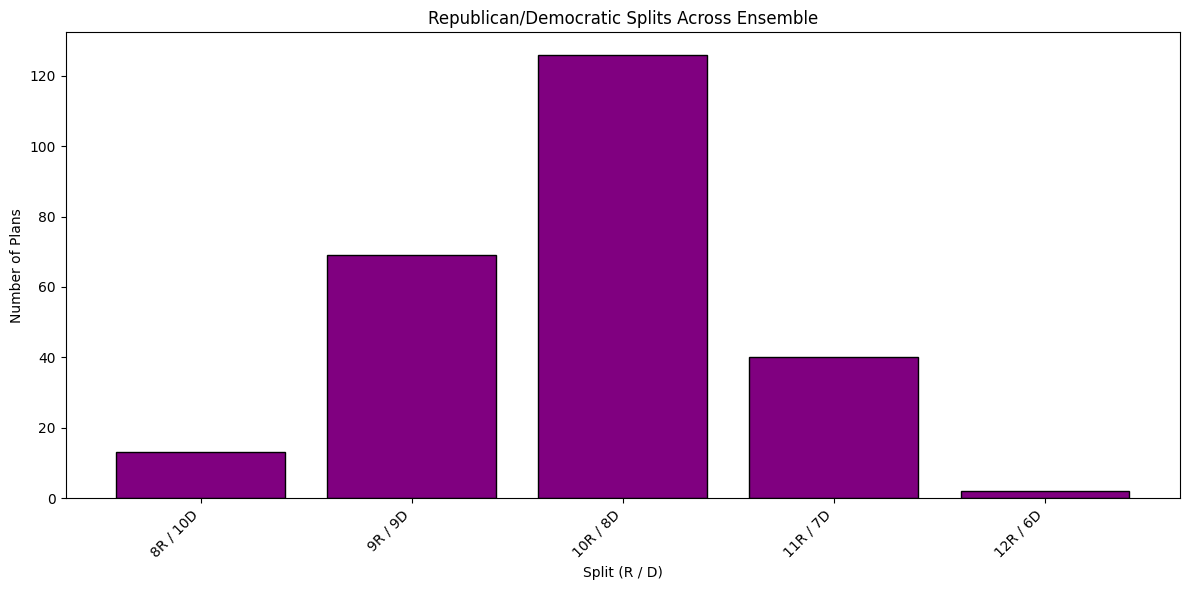

In [ ]:
import matplotlib.pyplot as plt

splits_counts = df.groupby(["Repub Seats", "Demo Seats"]).size().reset_index(name="Count")
print(splits_counts)

splits_counts["Split"] = (
    splits_counts["Repub Seats"].astype(int).astype(str) + "R / " +
    splits_counts["Demo Seats"].astype(int).astype(str) + "D"
)

splits_counts = splits_counts.sort_values("Repub Seats")

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(splits_counts["Split"], splits_counts["Count"], color="purple", edgecolor="black")

ax.set_xlabel("Split (R / D)")
ax.set_ylabel("Number of Plans")
ax.set_title("Republican/Democratic Splits Across Ensemble (PA)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
for i, partition in enumerate(ensemble):
    pops = partition["population"].values()
    print(f"Plan {i+1}: cut_edges={len(partition['cut_edges'])} | "
          f"min_pop={min(pops):,} | max_pop={max(pops):,}")

Matched: 8921 / 9255


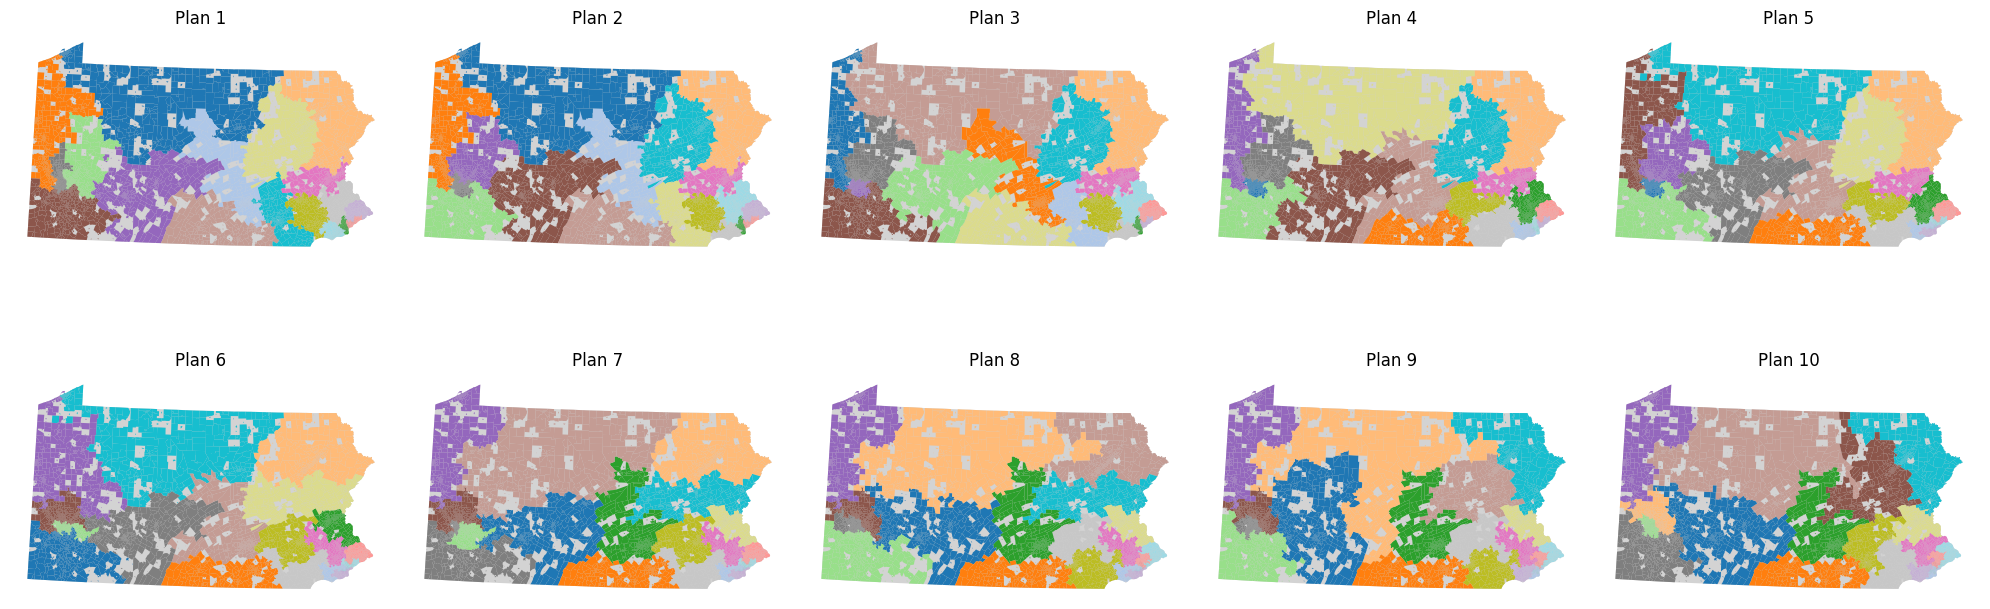

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

gdf = gpd.read_file("./PA_shape/PA.shp")

# Same matching approach as before
def geoid_to_key(geoid):
    state = geoid[:2]
    county = geoid[2:5]
    vtd = geoid[5:].lstrip('0') or '0'
    return (state, county, vtd)

id_to_geoid = {node: data["GEOID10"] for node, data in graph.nodes(data=True)}
key_to_geoid = {geoid_to_key(geoid): geoid for geoid in id_to_geoid.values()}

gdf["match_key"] = list(zip(
    gdf["STATEFP10"].astype(str),
    gdf["COUNTYFP10"].astype(str),
    gdf["VTDST10"].astype(str).str.lstrip('0').replace('', '0')
))

gdf["GEOID10_matched"] = gdf["match_key"].map(key_to_geoid)
print(f"Matched: {gdf['GEOID10_matched'].notna().sum()} / {len(gdf)}")

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, partition in enumerate(ensemble):

    if i >= 10:
        break

    geoid_to_district = {id_to_geoid[node]: district
                         for node, district in partition.assignment.items()}

    gdf["district"] = gdf["GEOID10_matched"].map(geoid_to_district)

    state_outline = gdf.dissolve()
    state_outline.plot(ax=axes[i], color="lightgray", edgecolor="none")

    gdf[gdf["district"].notna()].plot(
        column="district",
        ax=axes[i],
        cmap="tab20",
        legend=False,
        edgecolor="none",
        linewidth=0
    )
    axes[i].set_title(f"Plan {i+1}")
    axes[i].axis("off")

    

plt.tight_layout()
plt.show()

In [ ]:
for i, partition in enumerate(ensemble):
    print(f"Plan {i+1}")
    election_results = partition["PRES12"]
    districts = partition["population"].keys()

    dem_seats = election_results.seats("Dem")
    repub_seats = election_results.seats("Rep")
    print(f"D/R seats: ({dem_seats} / {repub_seats})")


    dem_districts = []
    repub_districts = []
    # iterate through each district
    for district in districts:
        # print(f"District {district}")
        dem = election_results.percents("Dem")[district-1]
        rep = election_results.percents("Rep")[district-1]
        
        if election_results.won("Dem", district):
            dem_districts.append(district)
        else:
            repub_districts.append(district)

        #print(district, dem, rep)
    print(f"Districts Dem Won: {dem_districts}")
    print(f"Districts Repub Won: {repub_districts}")

        

Plan 1
D/R seats: (9 / 9)
Districts Dem Won: [13, 4, 12, 14, 18, 15, 9, 7, 5]
Districts Repub Won: [3, 1, 6, 8, 2, 16, 11, 10, 17]
Plan 2
D/R seats: (9 / 9)
Districts Dem Won: [4, 12, 18, 15, 14, 9, 7, 13, 5]
Districts Repub Won: [3, 1, 8, 10, 2, 17, 11, 6, 16]
Plan 3
D/R seats: (9 / 9)
Districts Dem Won: [4, 12, 18, 15, 14, 7, 9, 8, 5]
Districts Repub Won: [11, 1, 13, 6, 3, 17, 16, 10, 2]
Plan 4
D/R seats: (8 / 10)
Districts Dem Won: [4, 12, 5, 2, 7, 9, 1, 18]
Districts Repub Won: [16, 8, 13, 10, 11, 17, 6, 3, 15, 14]
Plan 5
D/R seats: (8 / 10)
Districts Dem Won: [4, 12, 5, 2, 7, 18, 1, 9]
Districts Repub Won: [17, 10, 8, 13, 11, 16, 6, 3, 15, 14]
Plan 6
D/R seats: (8 / 10)
Districts Dem Won: [4, 12, 5, 2, 7, 18, 6, 9]
Districts Repub Won: [17, 8, 10, 13, 11, 16, 1, 3, 15, 14]
Plan 7
D/R seats: (8 / 10)
Districts Dem Won: [4, 6, 12, 16, 2, 7, 18, 9]
Districts Repub Won: [8, 10, 11, 1, 17, 5, 13, 3, 15, 14]
Plan 8
D/R seats: (8 / 10)
Districts Dem Won: [11, 12, 16, 2, 18, 7, 13, 9]
Dis